# 07 — DenseNet121-3D: 10-Fold Patient-Grouped Cross-Validation

**Run this on the lab machine (Ubuntu 22.04, RTX A4000, CUDA).** Not intended for Mac.

Protocol:
- 807 nodules, 506 patients, labels_v2.csv (binary labels, min_rad≥3, Option A)
- 10-fold GroupKFold by patient_id — zero patient leakage, asserted per fold
- Train augmentation: random-crop 40³→32³, 3-axis flips, 4³ dropout
- Val: center-crop 40³→32³, TTA (8 flip combinations)
- DenseNet121-3D with modified stem (3×3×3 s=1, no maxpool)
- AMP bfloat16, channels_last_3d, early stopping (patience=40)
- Metrics per fold: AUC, accuracy, sensitivity, specificity, precision, F1
- Ensemble section: fold-average probabilities (each nodule predicted once)

**Prerequisite:** Run `python scripts/verify_lab_setup.py` and `python scripts/autotune_batch_size.py` first.

In [1]:
import sys
from pathlib import Path
import os 

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'backend:cudaMallocAsync'

# Resolve repo root without hardcoding paths
_candidate = Path().resolve()
while _candidate != _candidate.parent:
    if (_candidate / 'src').is_dir() and (_candidate / 'configs').is_dir():
        break
    _candidate = _candidate.parent
sys.path.insert(0, str(_candidate))

from src.utils.paths import find_repo_root, get_data_dir
REPO_ROOT = find_repo_root()
DATA_DIR  = get_data_dir(REPO_ROOT)
print(f'REPO_ROOT : {REPO_ROOT}')
print(f'DATA_DIR  : {DATA_DIR}')

REPO_ROOT : /home/sreethanu/lung_cancer_vljepa
DATA_DIR  : /home/sreethanu/lung_cancer_vljepa/data


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import yaml
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

from src.utils.device import get_device
from src.models.densenet_3d import build_densenet, trace_feature_maps
from src.utils.dataloader import build_dataloaders, tta_predict
from src.training.cross_validation import run_cross_validation, compute_metrics

device = get_device()
print(f'Device: {device}')
assert device.type == 'cuda', (
    f'Expected CUDA device — got {device}. '
    'This notebook must run on the lab machine. Use notebook 05 for Mac sanity checks.'
)

cfg_path = REPO_ROOT / 'configs' / 'densenet_config.yaml'
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

print(f'Config         : {cfg_path}')
print(f'cv_folds       : {cfg["cv_folds"]}')
print(f'epochs         : {cfg["training"]["epochs"]}')
print(f'batch_size     : {cfg["data"]["batch_size"]}')
print(f'lr             : {cfg["training"]["lr"]}')
print(f'amp            : {cfg["training"]["amp"]}  ({cfg["training"]["amp_dtype"]})')
print(f'tta            : {cfg["tta"]}  ({len(cfg["tta_transforms"])} transforms)')
print(f'early_stop     : patience={cfg["training"]["early_stopping_patience"]}')

[device] CUDA selected — NVIDIA RTX A4000 (15.6 GB VRAM)
Device: cuda
Config         : /home/sreethanu/lung_cancer_vljepa/configs/densenet_config.yaml
cv_folds       : 10
epochs         : 200
batch_size     : 33
lr             : 0.001031
amp            : True  (float16)
tta            : True  (8 transforms)
early_stop     : patience=40


In [3]:
# Load labels and show distribution
labels_path = DATA_DIR / cfg['data']['labels_csv']
df = pd.read_csv(labels_path)

print(f'labels_v2.csv  : {len(df)} nodules  |  {df["patient_id"].nunique()} patients')
print(f'  benign   (0) : {(df["label"]==0).sum()} ({100*(df["label"]==0).mean():.1f}%)')
print(f'  malignant(1) : {(df["label"]==1).sum()} ({100*(df["label"]==1).mean():.1f}%)')
print(f'  avg_score    : {df["avg_score"].mean():.2f} ± {df["avg_score"].std():.2f}')

labels_v2.csv  : 807 nodules  |  506 patients
  benign   (0) : 422 (52.3%)
  malignant(1) : 385 (47.7%)
  avg_score    : 2.91 ± 1.20


In [4]:
# Optional: verify stem fix before starting long training
print('Verifying DenseNet stem modification and feature map shapes ...')
model_check = build_densenet(cfg).to(device)
trace_feature_maps(model_check, device)
del model_check
torch.cuda.empty_cache()
print()
print('Expected: conv0 output = (2, 64, 32, 32, 32), pool0 = Identity → same.')
print('Final feature map after 3 transitions should be ~(2, ?, 4, 4, 4).')

Verifying DenseNet stem modification and feature map shapes ...
[model] DenseNet121-3D (modified stem) | 11.22M parameters
[shape trace] Running dummy forward pass (2, 1, 32, 32, 32) ...
  stage                shape
  -------------------- -----
  conv0                (2, 64, 32, 32, 32)
  norm0                (2, 64, 32, 32, 32)
  relu0                (2, 64, 32, 32, 32)
  pool0                (2, 64, 32, 32, 32)
  denseblock1          (2, 256, 32, 32, 32)
  transition1          (2, 128, 16, 16, 16)
  denseblock2          (2, 512, 16, 16, 16)
  transition2          (2, 256, 8, 8, 8)
  denseblock3          (2, 1024, 8, 8, 8)
  transition3          (2, 512, 4, 4, 4)
  denseblock4          (2, 1024, 4, 4, 4)

  Peak VRAM (batch=2): 203.4 MB
[shape trace] done

Expected: conv0 output = (2, 64, 32, 32, 32), pool0 = Identity → same.
Final feature map after 3 transitions should be ~(2, ?, 4, 4, 4).


In [5]:
# ── Run full 10-fold CV ─────────────────────────────────────────────────────
# This cell will take several hours. Each fold trains for up to 200 epochs
# with early stopping. Checkpoints saved to checkpoints/densenet/fold_N.pth.
# A cv_summary.csv is written at the end.

cv_results = run_cross_validation(cfg)
print('\nCV complete.')

[device] CUDA selected — NVIDIA RTX A4000 (15.6 GB VRAM)

FOLD 1/10
  train: 726 nodules / 456 patients
  val  : 81 nodules  / 50 patients
  Preloading 726 patches to RAM... done (177.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  epoch 001/200  loss=0.5972  val_auc=0.5364
  epoch 002/200  loss=0.5228  val_auc=0.3151
  epoch 003/200  loss=0.4677  val_auc=0.8438
  epoch 004/200  loss=0.4241  val_auc=0.8699
  epoch 005/200  loss=0.4008  val_auc=0.8941
  epoch 006/200  loss=0.3913  val_auc=0.8686
  epoch 007/200  loss=0.3998  val_auc=0.5733
  epoch 008/200  loss=0.3752  val_auc=0.9094
  epoch 009/200  loss=0.3530  val_auc=0.9598
  epoch 010/200  loss=0.3531  val_auc=0.8807
  epoch 011/200  loss=0.3637  val_auc=0.6320
  epoch 012/200  loss=0.3475  val_auc=0.9273
  epoch 013/200  loss=0.3335  val_auc=0.9471
  epoch 014/200  loss=0.3232  val_auc=0.9534
  epoch 015/200  loss=0.3049  val_auc=0.8935
  epoch 016/200  loss=0.299

In [6]:
# ── Per-fold metrics table ──────────────────────────────────────────────────
fold_metrics = [r['metrics'] for r in cv_results['fold_results']]
metric_keys  = ['auc', 'accuracy', 'sensitivity', 'specificity', 'precision', 'f1']

rows = []
for i, m in enumerate(fold_metrics, start=1):
    row = {'fold': i}
    row.update({k: round(m[k], 4) for k in metric_keys})
    row['best_epoch'] = m.get('best_epoch', '?')
    rows.append(row)

# Summary row
means = {k: np.mean([m[k] for m in fold_metrics]) for k in metric_keys}
stds  = {k: np.std( [m[k] for m in fold_metrics]) for k in metric_keys}
rows.append({'fold': 'mean±std', **{k: f"{means[k]:.4f}±{stds[k]:.4f}" for k in metric_keys}})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

    fold           auc      accuracy   sensitivity   specificity     precision            f1  best_epoch
       1        0.9758        0.9259         0.875        0.9592        0.9333        0.9032        44.0
       2        0.9689        0.9506        0.9762        0.9231        0.9318        0.9535        69.0
       3        0.9916        0.9383           1.0        0.9091        0.8387        0.9123        48.0
       4        0.9665        0.8889         0.878           0.9           0.9        0.8889        72.0
       5        0.9787        0.9136          0.92        0.9032        0.9388        0.9293        33.0
       6        0.9725        0.9012        0.8095           1.0           1.0        0.8947        39.0
       7        0.9784        0.9136           0.9        0.9216         0.871        0.8852        39.0
       8        0.9851        0.9125         0.875           1.0           1.0        0.9333        47.0
       9        0.9887        0.9125        0.8947     

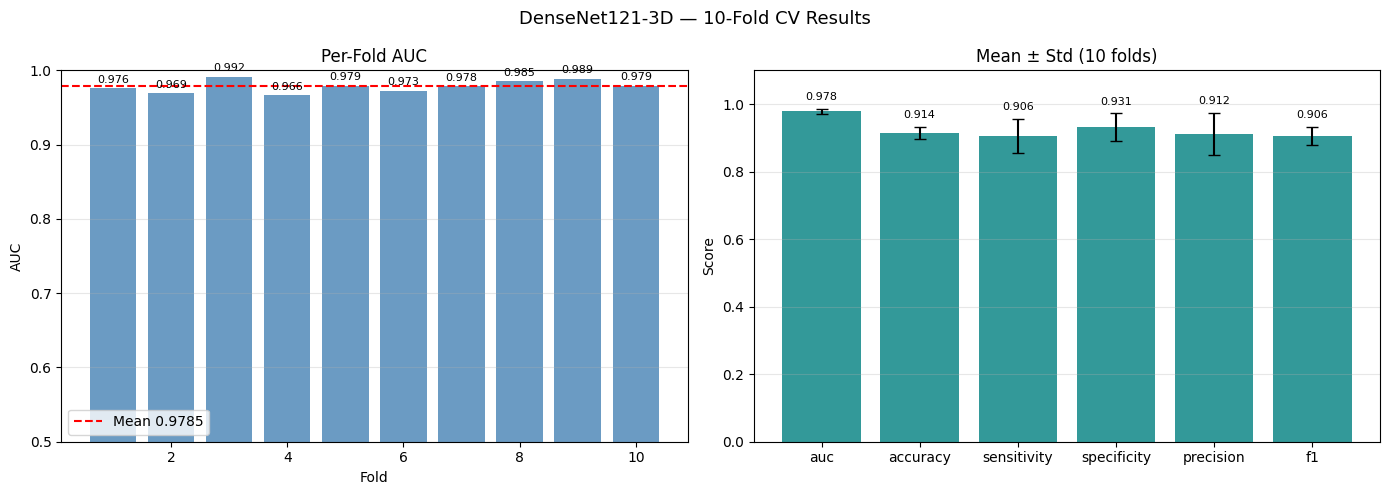

In [8]:
# ── AUC box plot across folds ───────────────────────────────────────────────
fold_aucs = [m['auc'] for m in fold_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-fold AUC bar
ax = axes[0]
bars = ax.bar(range(1, len(fold_aucs)+1), fold_aucs, color='steelblue', alpha=0.8)
ax.axhline(np.mean(fold_aucs), ls='--', color='red', label=f'Mean {np.mean(fold_aucs):.4f}')
ax.set(xlabel='Fold', ylabel='AUC', title='Per-Fold AUC', ylim=(0.5, 1.0))
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, fold_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Right: all metrics as grouped bars
ax = axes[1]
x = np.arange(len(metric_keys))
means_list = [means[k] for k in metric_keys]
stds_list  = [stds[k]  for k in metric_keys]
ax.bar(x, means_list, yerr=stds_list, capsize=4, color='teal', alpha=0.8)
ax.set(xticks=x, xticklabels=metric_keys, ylabel='Score', title='Mean ± Std (10 folds)', ylim=(0, 1.1))
ax.grid(axis='y', alpha=0.3)
for xi, (m, s) in zip(x, zip(means_list, stds_list)):
    ax.text(xi, m + s + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('DenseNet121-3D — 10-Fold CV Results', fontsize=13)
plt.tight_layout()
(REPO_ROOT / 'experiments').mkdir(parents=True, exist_ok=True)
plt.savefig(REPO_ROOT / 'experiments' / 'densenet_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Ensemble metrics (fold-averaged probabilities) ──────────────────────────
# Each nodule is predicted exactly once (in its held-out val fold).
# Ensemble = average of the 10 fold models' softmax over THAT nodule's val fold.
# This is the number to report in the paper.

ens = cv_results['ensemble_metrics']
print('=== Ensemble Metrics (each nodule predicted once, fold-averaged probabilities) ===')
for k in metric_keys:
    print(f'  {k:<14} {ens[k]:.4f}')

print()
print('=== 10-Fold CV Mean ± Std ===')
for k in metric_keys:
    print(f'  {k:<14} {means[k]:.4f} ± {stds[k]:.4f}')

=== Ensemble Metrics (each nodule predicted once, fold-averaged probabilities) ===
  auc            0.9724
  accuracy       0.9145
  sensitivity    0.9013
  specificity    0.9265
  precision      0.9180
  f1             0.9096

=== 10-Fold CV Mean ± Std ===
  auc            0.9785 ± 0.0078
  accuracy       0.9145 ± 0.0189
  sensitivity    0.9057 ± 0.0516
  specificity    0.9310 ± 0.0412
  precision      0.9120 ± 0.0630
  f1             0.9060 ± 0.0270


In [10]:
# ── TTA ablation: compare identity-only vs all-8-flips ──────────────────────
# Reload fold checkpoints and re-evaluate with identity-only TTA to quantify
# the TTA gain.

from sklearn.model_selection import GroupKFold

save_dir   = REPO_ROOT / cfg['training']['save_dir']
gkf        = GroupKFold(n_splits=cfg['cv_folds'])
groups     = df['patient_id'].values
tta_names  = ['identity_only', 'all_8_flips']
tta_sets   = [['identity'], cfg['tta_transforms']]

tta_results = {name: [] for name in tta_names}

for fold, (train_idx, val_idx) in enumerate(gkf.split(df, df['label'], groups), start=1):
    ckpt_path = save_dir / f'fold_{fold}.pth'
    if not ckpt_path.exists():
        print(f'  Fold {fold}: checkpoint not found, skipping')
        continue

    val_df = df.iloc[val_idx].copy()
    _, val_loader = build_dataloaders(cfg, df.iloc[:1].copy(), val_df)  # dummy train_df

    model_eval = build_densenet(cfg).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model_eval.load_state_dict(ckpt['model_state_dict'])
    model_eval.eval()

    y_true = df.iloc[val_idx]['label'].values

    for name, transforms in zip(tta_names, tta_sets):
        probs = []
        with torch.no_grad():
            for x, _ in val_loader:
                p = tta_predict(model_eval, x, transforms, device)
                probs.append(p.cpu().numpy())
        y_prob = np.concatenate(probs)[:, 1]
        tta_results[name].append(float(roc_auc_score(y_true, y_prob)))

    del model_eval
    torch.cuda.empty_cache()

print('TTA Ablation — AUC per fold:')
for name in tta_names:
    vals = tta_results[name]
    if vals:
        print(f'  {name:<20} {np.mean(vals):.4f} ± {np.std(vals):.4f}')

  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches to RAM... done (19.8 MB)
[model] DenseNet121-3D (modified stem) | 11.22M parameters
  Preloading 1 patches to RAM... done (0.2 MB)
  Preloading 81 patches

In [11]:
# ── Save final summary ──────────────────────────────────────────────────────
exp_dir = REPO_ROOT / 'experiments'
exp_dir.mkdir(parents=True, exist_ok=True)

out_path = exp_dir / 'densenet_cv_summary.txt'
with open(out_path, 'w') as f:
    f.write('DenseNet121-3D — 10-Fold Patient-Grouped CV\n')
    f.write(f'labels_v2.csv: {len(df)} nodules, {df["patient_id"].nunique()} patients\n')
    f.write(f'Label rule: benign<=2.5, malignant>=3.5, min_rad>=3\n\n')
    f.write('Per-fold metrics:\n')
    for i, m in enumerate(fold_metrics, 1):
        f.write(f'  Fold {i:2d}: ' + '  '.join(f'{k}={m[k]:.4f}' for k in metric_keys) + '\n')
    f.write('\nMean ± Std:\n')
    for k in metric_keys:
        vals = [m[k] for m in fold_metrics]
        f.write(f'  {k:<14} {np.mean(vals):.4f} ± {np.std(vals):.4f}\n')
    f.write('\nEnsemble (fold-averaged probabilities):\n')
    for k in metric_keys:
        f.write(f'  {k:<14} {ens[k]:.4f}\n')

print(f'Summary saved → {out_path}')

Summary saved → /home/sreethanu/lung_cancer_vljepa/experiments/densenet_cv_summary.txt
